In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


data = np.genfromtxt(
    "PS_2026.04.21_03.28.15.csv",
    delimiter=",",
    comments="#",
    dtype=float,
    filling_values=np.nan
)


data = np.delete(data, [1,2,3,7,9,10,11], axis=1) #delete errors and limit flag

data1 = []

for n in range(len(data)):
    if (np.isnan(data[n,:]).any() == False):
        data1.append(data[n, :])

data1 = np.array(data1)
data2  = np.array(data1)

for n in range(len(data2)):
    data2[n,2] = (data2[n,2] - data2[n,3])/2 #take the mean of the 2 errors

sample_a = np.delete(data2,3, axis = 1)

In [94]:
print("number of planets in the dataset: ", len(sample_a))

number of planets in the dataset:  2914


In [95]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [96]:
sample_b = []
for n in range(len(sample_a)):
    if (sample_a[n,0] <= 5):
        sample_b.append(sample_a[n,0])
sample_b = np.array(sample_b)

In [97]:
print("number of planets in sample b: ", len(sample_b))

number of planets in sample b:  1145


Text(0, 0.5, 'planetary mass [Earth Mass]')

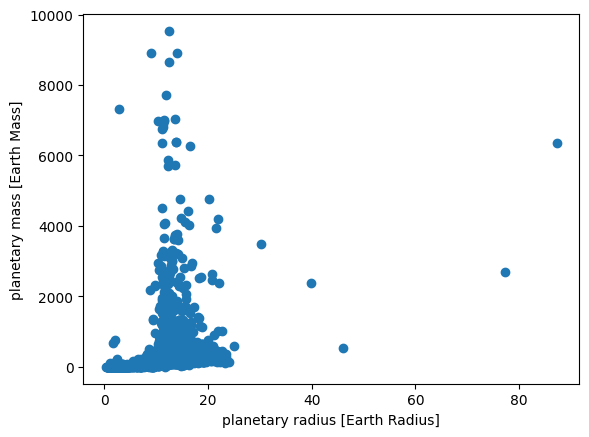

In [98]:
plt.scatter(sample_a[:,0], sample_a[:,1])
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [99]:
planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
error_m = sample_a[:, 2].copy()
stellar_m = sample_a[:, 3].copy()

# log Transformation
log_planet_r = np.log(planet_r)
log_stellar_m = np.log(stellar_m)
log_planet_m = np.log(planet_m)
log_error_m = error_m / (planet_m) # relative error (we can't just apply logarithmic transformation to the error)

log_sample_a = np.column_stack((log_planet_r, log_planet_m, log_error_m, log_stellar_m))

In [100]:
(sample_a[:,1] == data2[:,1]).all()

np.True_

In [101]:
(log_sample_a[:,3] == log_error_m).all()

np.False_

In [102]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

Text(0, 0.5, 'planetary mass [Earth Mass]')

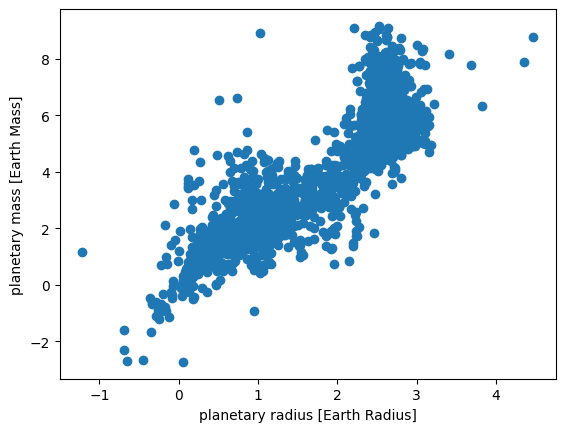

In [103]:
plt.scatter(log_sample_a[:,0], log_sample_a[:,1])
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [104]:
#derive log sample_b:

log_sample_b = []
for n in range(len(log_sample_a)):
    if (log_sample_a[n,0] <= np.log(5)):
        log_sample_b.append(log_sample_a[n,:])
log_sample_b = np.array(log_sample_b)

In [105]:
np.shape(log_sample_b)

(1145, 4)

## Linear Regression

Ignoring the uncertainties associated with the mass measurements, use a 1D linear regression model
to fit sample_B:

Text(0, 0.5, 'planetary mass [Earth Mass]')

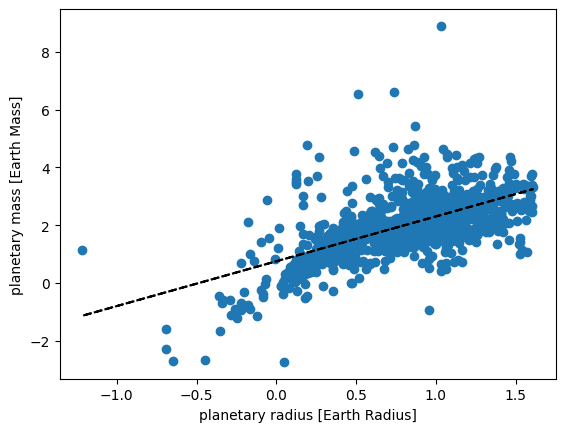

In [106]:
a,b = np.polyfit(log_sample_b[:,0], log_sample_b[:,1], 1)
poly1d_fn = np.poly1d((a,b)) #since we are in log space it makes sense to use an intercept
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(log_sample_b[:,0], log_sample_b[:,1],"o", log_sample_b[:,0], poly1d_fn(log_sample_b[:,0]), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')

In [107]:
solar_planets = np.array([[2439.4, 0.330103e24, 0.000021e24],   #mean radius (because I think it says more about mass
                          [6051.8, 4.86731e24, 0.00023e24],
                          [6371.0084, 5.97217e24, 0.00028e24],
                          [3389.50, 0.641691e24, 0.000030e24],
                          [69911, 1898.125e24, 0.088e24],
                          [58232, 568.317e24, 0.026e24],
                          [25362, 86.8099e24, 0.0040e24],
                          [24622, 102.4092e24, 0.0048e24]])

solar_planets[:,0] = solar_planets[:,0] / 6378 #converting radius km -> earth radius
solar_planets[:,1] = solar_planets[:,1] /5.972e+24
solar_planets[:,2] = solar_planets[:,2] /5.972e+24

solarplanet_r = solar_planets[:, 0].copy() #apply logarithmic transformation
solarplanet_m = solar_planets[:, 1].copy()
solarerror_m = solar_planets[:, 2].copy()


# log Transformation
log_solarplanet_r = np.log(solarplanet_r)
log_solarplanet_m = np.log(solarplanet_m)
log_solarerror_m = solarerror_m / (solarplanet_m) # relative error (we can't just apply logarithmic transformation to the error)

log_solar_planets = np.column_stack((log_solarplanet_r,log_solarplanet_m, log_solarerror_m))


In [108]:
# Notiz: auf sample a gefittet, werden die planeten besser approximiert!

Text(0, 0.5, 'planetary mass of solar planets [Earth Mass]')

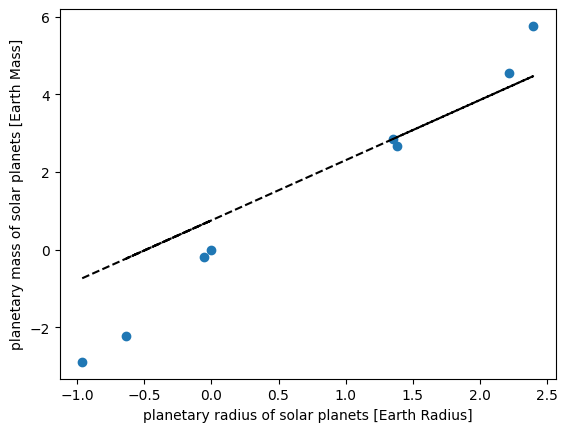

In [109]:
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(log_solarplanet_r,log_solarplanet_m,"o", log_solarplanet_r, poly1d_fn(log_solarplanet_r), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius of solar planets [Earth Radius]')
plt.ylabel('planetary mass of solar planets [Earth Mass]')

In [110]:
def linear_model(x, a, b):
    return a * x + b

popt, pcov = curve_fit(
    linear_model,
    log_sample_b[:,0],
    log_sample_b[:,1],
    sigma=log_sample_b[:,2],
    absolute_sigma=True
)

a_3, b_3 = popt

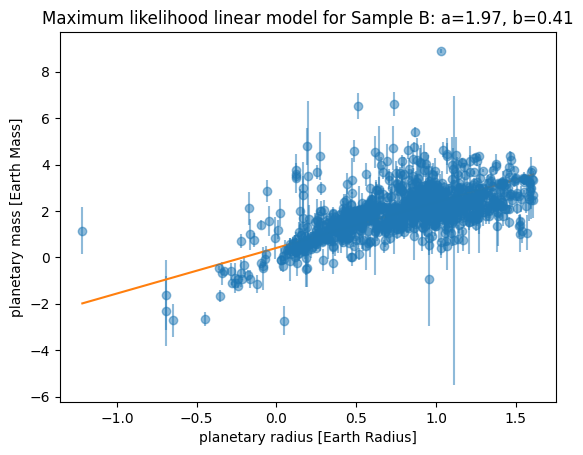

In [111]:
x_fit = np.linspace(min(log_sample_b[:,0]), max(log_sample_b[:,0]), 100)
y_fit = linear_model(x_fit, a_3, b_3)

plt.errorbar(log_sample_b[:,0], log_sample_b[:,1], yerr=log_sample_b[:,2], fmt='o', alpha=0.5)
plt.plot(x_fit, y_fit)

plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.title(f"Maximum likelihood linear model for Sample B: a={a_3:.2f}, b={b_3:.2f}")
plt.show()

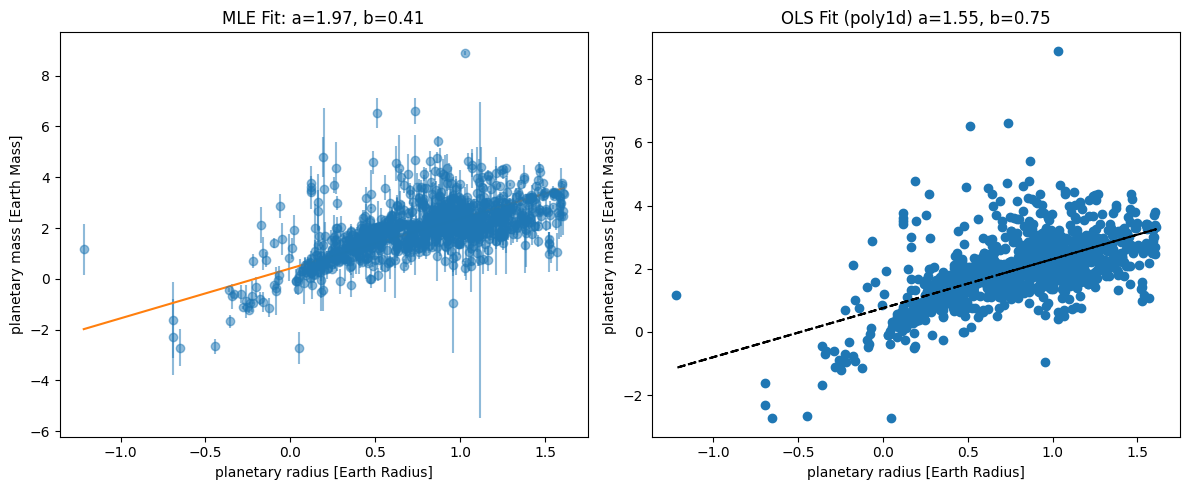

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Plot 1: mit Fehlerbalken + Fit
axs[0].errorbar(log_sample_b[:,0], log_sample_b[:,1], yerr=log_sample_b[:,2], fmt='o', alpha=0.5)
axs[0].plot(x_fit, y_fit)

axs[0].set_xlabel('planetary radius [Earth Radius]')
axs[0].set_ylabel('planetary mass [Earth Mass]')
axs[0].set_title(f"MLE Fit: a={a_3:.2f}, b={b_3:.2f}")


# 🔹 Plot 2: einfacher Fit (poly1d)
axs[1].plot(log_sample_b[:,0], log_sample_b[:,1], 'o')
axs[1].plot(log_sample_b[:,0], poly1d_fn(log_sample_b[:,0]), '--k')

axs[1].set_xlabel('planetary radius [Earth Radius]')
axs[1].set_ylabel('planetary mass [Earth Mass]')
axs[1].set_title(f"OLS Fit (poly1d) a={a:.2f}, b={b:.2f}")


plt.tight_layout()
plt.show()

In [113]:
def poly_model(x, a, b, c):
    return a+ b*x + c* (x**2) #+ 0*d* (x**3)

popt_poly, pcov_poly = curve_fit(
    poly_model,
    log_sample_a[:,0],
    log_sample_a[:,1],
    sigma=log_sample_a[:,2],
    absolute_sigma=True
)

a_poly, b_poly, c_poly = popt_poly

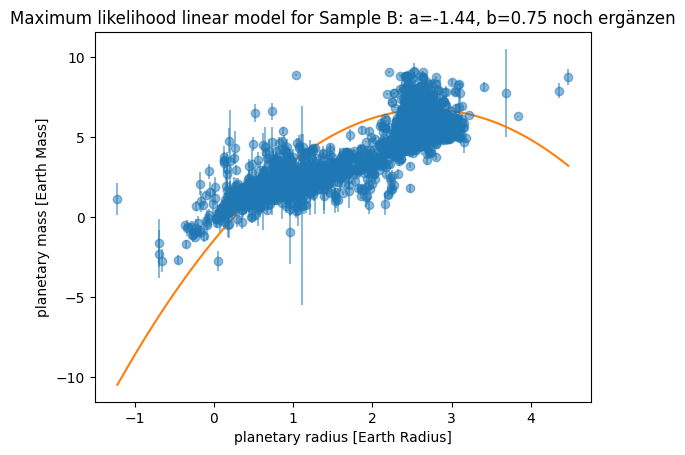

In [114]:
x_fit_poly = np.linspace(min(log_sample_a[:,0]), max(log_sample_a[:,0]), 100)
y_fit_poly = poly_model(x_fit_poly, a_poly, b_poly, c_poly)

plt.errorbar(log_sample_a[:,0], log_sample_a[:,1], yerr=log_sample_a[:,2], fmt='o', alpha=0.5)
plt.plot(x_fit_poly, y_fit_poly)

plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.title(f"Maximum likelihood linear model for Sample B: a={a_poly:.2f}, b={b:.2f} noch ergänzen")
plt.show()

Text(0, 0.5, 'planetary mass of solar planets [Earth Mass]')

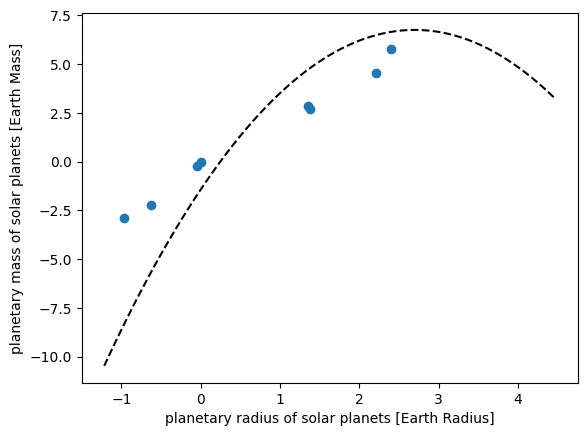

In [115]:
plt.plot(log_solarplanet_r,log_solarplanet_m,"o", x_fit_poly, y_fit_poly, '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel('planetary radius of solar planets [Earth Radius]')
plt.ylabel('planetary mass of solar planets [Earth Mass]')

POLYNOMIALS


In [116]:
def polynomial_model(x, *coeffs):
    """
    Polynomial model:
    log(M) = a0 + a1*log(R) + a2*log(R)^2 + ... + ad*log(R)^d

    coeffs = (a0, a1, ..., ad)
    """
    y = np.zeros_like(x, dtype=float)

    for k, a_k in enumerate(coeffs):
        y += a_k * x**k

    return y

In [117]:
d = 2 # change this later to test different degrees

initial_guess = np.ones(d + 1)

popt, pcov = curve_fit(
    polynomial_model,
    log_sample_a[:, 0],   # log radius
    log_sample_a[:, 1],   # log mass
    sigma=log_sample_a[:, 2],
    absolute_sigma=True,
    p0=initial_guess
)

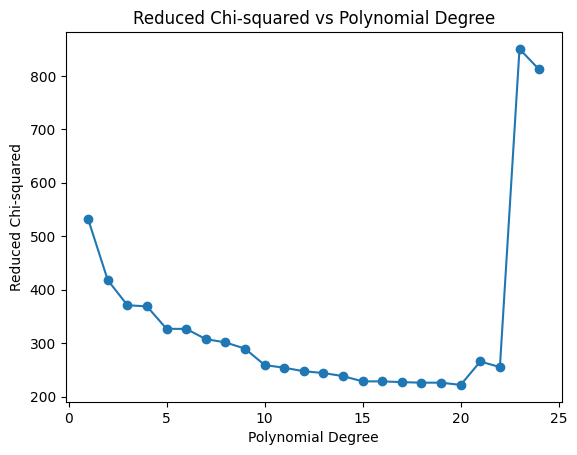

    degree          chi2  reduced_chi2           AIC            BIC
19      20  641327.48032    221.682503  641369.48032  641495.003242
0.0011286952740978753
[0.01957654 0.03192225 0.12003976 0.59005738]


In [118]:
x_data = log_sample_a[:, 0]   # log radius
y_data = log_sample_a[:, 1]   # log mass
y_err  = log_sample_a[:, 2]   # error in log mass

results = []

for d in range(1, 25):
    initial_guess = np.ones(d + 1)

    popt, pcov = curve_fit(
        polynomial_model,
        x_data,
        y_data,
        sigma=y_err,
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=10000
    )

    y_model = polynomial_model(x_data, *popt)

    residuals = y_data - y_model
    chi2 = np.sum((residuals / y_err)**2)

    n = len(y_data)
    k = d + 1

    aic = chi2 + 2*k
    bic = chi2 + k*np.log(n)
    reduced_chi2 = chi2 / (n - k)

    results.append([d, chi2, reduced_chi2, aic, bic, popt])

results_df = pd.DataFrame(
    results,
    columns=["degree", "chi2", "reduced_chi2", "AIC", "BIC", "coefficients"]
)

results_df
plt.plot(results_df["degree"], results_df["reduced_chi2"], marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Reduced Chi-squared")
plt.title("Reduced Chi-squared vs Polynomial Degree")
plt.show()
print(results_df[results_df["reduced_chi2"] == results_df["reduced_chi2"].min()]
      [["degree", "chi2", "reduced_chi2", "AIC", "BIC"]])
print(np.min(y_err))
print(np.percentile(y_err, [1, 5, 50, 95]))


In [119]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x_data = log_sample_a[:, 0]
y_data = log_sample_a[:, 1]
y_err  = log_sample_a[:, 2]

mask = y_err > 0
x_data = x_data[mask]
y_data = y_data[mask]
y_err = y_err[mask]

x_train, x_val, y_train, y_val, err_train, err_val = train_test_split(
    x_data,
    y_data,
    y_err,
    test_size=0.3,
    random_state=42
)

validation_results = []

for d in range(1, 21):
    initial_guess = np.ones(d + 1)

    popt, pcov = curve_fit(
        polynomial_model,
        x_train,
        y_train,
        sigma=err_train,
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=10000
    )

    y_train_pred = polynomial_model(x_train, *popt)
    y_val_pred = polynomial_model(x_val, *popt)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    weighted_val_mse = np.mean(((y_val - y_val_pred) / err_val)**2)

    validation_results.append([d, train_mse, val_mse, weighted_val_mse, popt])

validation_df = pd.DataFrame(
    validation_results,
    columns=["degree", "train_mse", "val_mse", "weighted_val_mse", "coefficients"]
)

validation_df

,degree,train_mse,val_mse,weighted_val_mse,coefficients
0,1,2.100261,2.250422e+00,3.966975e+02,"[1.0472898739866334, 2.273787883808824]"
1,2,2.386897,2.505607e+00,3.169425e+02,"[-1.4152063478793009, 6.068975200227591, -1.11..."
2,3,1.854173,2.172337e+00,2.860677e+02,"[0.22777948936464235, 0.44533106892438123, 2.5..."
3,4,1.977364,2.150021e+00,2.855159e+02,"[0.40504703590641367, -1.3623710052085387, 5.1..."
4,5,3.535185,2.643635e+00,2.658324e+02,"[0.666054558611886, 5.532608046517081, -12.667..."
5,6,3.077135,2.828029e+00,2.657605e+02,"[0.5996780935280019, 5.382965345870558, -11.37..."
6,7,5.654631,2.987444e+00,2.570648e+02,"[-0.0140338384634689, 7.4293894583378055, -4.2..."
7,8,3.613159,1.845333e+01,3.063312e+02,"[-0.3500641707975498, 4.439155287548518, 6.066..."
8,9,2.548241,5.541969e+00,2.567562e+02,"[-0.9168926262788946, 3.456652083876582, 18.58..."
9,10,2.869710,5.628584e+00,2.471380e+02,"[0.9600515636726307, 0.03307212640518727, -18...."


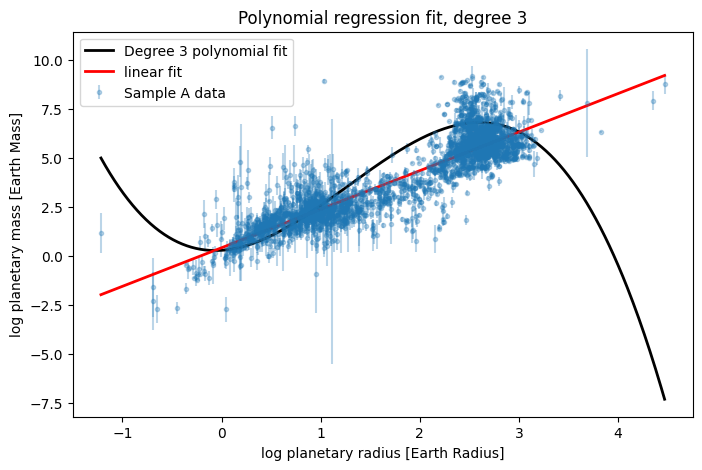

In [120]:
d_best = 3

# Final polynomial fit on all of Sample A
popt_best, pcov_best = curve_fit(
    polynomial_model,
    x_data,
    y_data,
    sigma=y_err,
    absolute_sigma=True,
    p0=np.ones(d_best + 1),
    maxfev=10000
)

best_coeffs = popt_best

# Predictions for plotting
x_fit = np.linspace(min(x_data), max(x_data), 500)
y_fit = polynomial_model(x_fit, *best_coeffs)
y_linear = linear_model(x_fit, a_3, b_3) # linear model predictions

plt.figure(figsize=(8, 5))


plt.errorbar(
    x_data,
    y_data,
    yerr=y_err,
    fmt="o",
    alpha=0.3,
    markersize=3,
    label="Sample A data"
)

plt.plot(
    x_fit,
    y_fit,
    color="black",
    linewidth=2,
    label=f"Degree {d_best} polynomial fit"
)

plt.plot(
    x_fit,
    y_linear,
    color="red",
    linewidth=2,
    label=f"linear fit"
)

plt.xlabel("log planetary radius [Earth Radius]")
plt.ylabel("log planetary mass [Earth Mass]")
plt.title(f"Polynomial regression fit, degree {d_best}")
plt.legend()
plt.show()


In [121]:
# Solar System planet names in the same order as your solar_planets array
solar_names = np.array([
    "Mercury", "Venus", "Earth", "Mars",
    "Jupiter", "Saturn", "Uranus", "Neptune"
])

solar_type = np.array([
    "Rocky", "Rocky", "Rocky", "Rocky",
    "Gas giant", "Gas giant", "Ice giant", "Ice giant"
])
# x and y for Solar System planets
x_solar = log_solarplanet_r
y_solar_true = log_solarplanet_m

# predictions from linear model
y_solar_linear = linear_model(x_solar, a_3, b_3) # c=0 for linear model

# predictions from polynomial model
y_solar_poly = polynomial_model(x_solar, *best_coeffs)

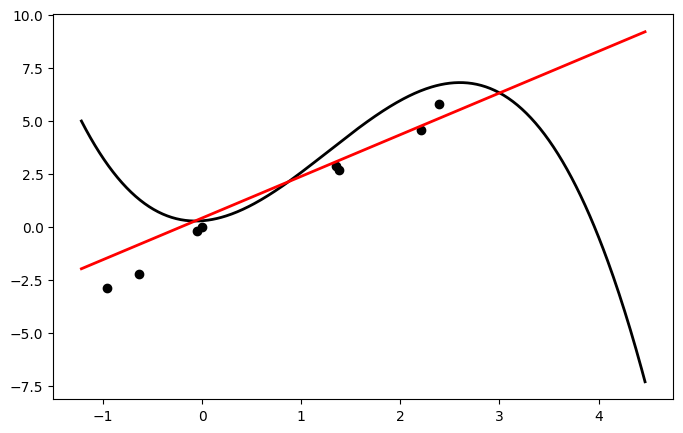

In [122]:
#plot the Solar System planets with the fits
plt.figure(figsize=(8, 5))
plt.plot(
    x_solar,
    y_solar_true,
    "o",
    color="black",
    label="Solar System planets"
)
plt.plot(
    x_fit,
    y_fit,
    color="black",
    linewidth=2,
    label=f"Degree {d_best} polynomial fit"
)

plt.plot(
    x_fit,
    y_linear,
    color="red",
    linewidth=2,
    label=f"linear fit"
)

In [123]:
mse_linear_rocky = mean_squared_error(y_solar_true[:4], y_solar_linear[:4])
mse_poly_rocky = mean_squared_error(y_solar_true[:4], y_solar_poly[:4])
print(f"MSE for linear model (rocky planets): {mse_linear_rocky:.4f}")
print(f"MSE for polynomial model (rocky planets): {mse_poly_rocky:.4f}")
mse_linear_gas = mean_squared_error(y_solar_true[4:6], y_solar_linear[4:6])
mse_poly_gas = mean_squared_error(y_solar_true[4:6], y_solar_poly[4:6])
print(f"MSE for linear model (gas giants): {mse_linear_gas:.4f}")
print(f"MSE for polynomial model (gas giants): {mse_poly_gas:.4f}")
mse_linear_ice = mean_squared_error(y_solar_true[6:8], y_solar_linear[6:8])
mse_poly_ice = mean_squared_error(y_solar_true[6:8], y_solar_poly[6:8])
print(f"MSE for linear model (ice giants): {mse_linear_ice:.4f}")
print(f"MSE for polynomial model (ice giants): {mse_poly_ice:.4f}")

MSE for linear model (rocky planets): 1.0921
MSE for polynomial model (rocky planets): 11.8005
MSE for linear model (gas giants): 0.2299
MSE for polynomial model (gas giants): 2.1577
MSE for linear model (ice giants): 0.1226
MSE for polynomial model (ice giants): 1.2916


In [124]:
# 2D linear model:
# log M_planet = a*log R_planet + b*log M_star + c

def linear_2d_model(X, a, b, c):
    log_R, log_Mstar = X
    return a * log_R + b * log_Mstar + c


x_radius = log_sample_a[:, 0]
x_stellar = log_sample_a[:, 3]
y_mass = log_sample_a[:, 1]
y_err = log_sample_a[:, 2]

mask = y_err > 0
x_radius = x_radius[mask]
x_stellar = x_stellar[mask]
y_mass = y_mass[mask]
y_err = y_err[mask]

popt_2d, pcov_2d = curve_fit(
    linear_2d_model,
    (x_radius, x_stellar),
    y_mass,
    sigma=y_err,
    absolute_sigma=True,
    p0=np.ones(3),
    maxfev=10000
)

a_2d, b_2d, c_2d = popt_2d
print(a_2d, b_2d, c_2d)

1.963464071613981 0.7559378595354608 1.6713883276823371


In [125]:
# 1D linear baseline on full Sample A
def linear_1d_model(x, a, b):
    return a * x + b

popt_1d_A, pcov_1d_A = curve_fit(
    linear_1d_model,
    x_radius,
    y_mass,
    sigma=y_err,
    absolute_sigma=True,
    p0=np.ones(2),
    maxfev=10000
)

y_solar_1d_A = linear_1d_model(x_solar, *popt_1d_A)
# For Solar System planets, the host star is the Sun.
# Since stellar masses are in solar-mass units, log(M_star) = log(1) = 0.
log_solar_stellar_mass = np.zeros_like(x_solar)

y_solar_2d = linear_2d_model(
    (x_solar, log_solar_stellar_mass),
    *popt_2d
)



In [126]:
mse_1d_A = mean_squared_error(y_solar_true, y_solar_1d_A)
mse_2d_A = mean_squared_error(y_solar_true, y_solar_2d)
print(f"1D linear Sample A MSE: {mse_1d_A:.4f}")
print(f"2D linear Sample A MSE: {mse_2d_A:.4f}")

1D linear Sample A MSE: 1.8458
2D linear Sample A MSE: 3.4741


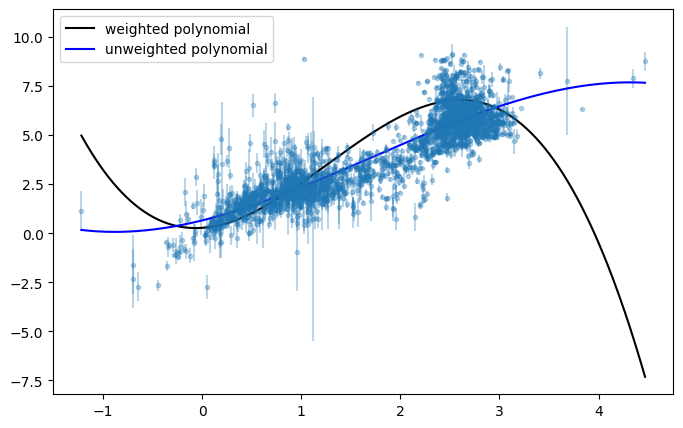

In [127]:
d_best = 3
popt_poly_unweighted, _ = curve_fit(
    polynomial_model,
    x_data,
    y_data,
    p0=np.ones(d_best + 1),
    maxfev=10000
)

y_fit_unweighted = polynomial_model(x_fit, *popt_poly_unweighted)

plt.figure(figsize=(8, 5))
plt.errorbar(x_data, y_data, yerr=y_err, fmt="o", alpha=0.3, markersize=3)
plt.plot(x_fit, y_fit, "k", label="weighted polynomial")
plt.plot(x_fit, y_fit_unweighted, "blue", label="unweighted polynomial")
plt.legend()
plt.show()


In [128]:
print(np.percentile(y_err, [0, 1, 5, 50, 95, 99, 100]))


[1.12869527e-03 1.95765425e-02 3.19222526e-02 1.20039762e-01
 5.90057377e-01 1.01220426e+00 6.22463768e+00]


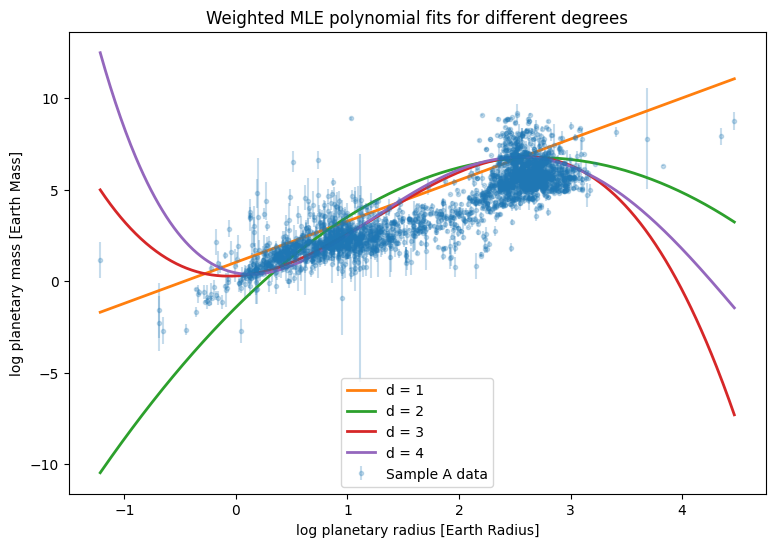

In [129]:
degrees = range(1, 5)

x_fit = np.linspace(min(x_data), max(x_data), 500)

plt.figure(figsize=(9, 6))

plt.errorbar(
    x_data,
    y_data,
    yerr=y_err,
    fmt="o",
    alpha=0.25,
    markersize=3,
    label="Sample A data"
)

for d in degrees:
    popt_d, pcov_d = curve_fit(
        polynomial_model,
        x_data,
        y_data,
        sigma=y_err,
        absolute_sigma=True,
        p0=np.ones(d + 1),
        maxfev=10000
    )

    y_fit_d = polynomial_model(x_fit, *popt_d)

    plt.plot(
        x_fit,
        y_fit_d,
        linewidth=2,
        label=f"d = {d}"
    )

plt.xlabel("log planetary radius [Earth Radius]")
plt.ylabel("log planetary mass [Earth Mass]")
plt.title("Weighted MLE polynomial fits for different degrees")
plt.legend()
plt.show()
